In [1]:
#%% Import 
import os
import sys
import getopt
import h5py as h5
import numpy as np
import pandas as pd
import datetime as dt
import daz_lib_licsar as dl
import xarray as xr
import matplotlib.pyplot as plt
import lics_unwrap as lu

setting pyproj data directory


In [2]:
framedir='/gws/nopw/j04/nceo_geohazards_vol1/public/LiCSAR_products/116/116A_05207_252525/epochs/20180101'
frame=os.path.basename(framedir)
e_file=f'{framedir}/tmp_tides.e.nc'
n_file=f'{framedir}/tmp_tides.n.nc'
u_file=f'{framedir}/tmp_tides.v.nc'


In [3]:
efile = xr.load_dataset(e_file)
nfile = xr.load_dataset(n_file)
ufile = xr.load_dataset(u_file)

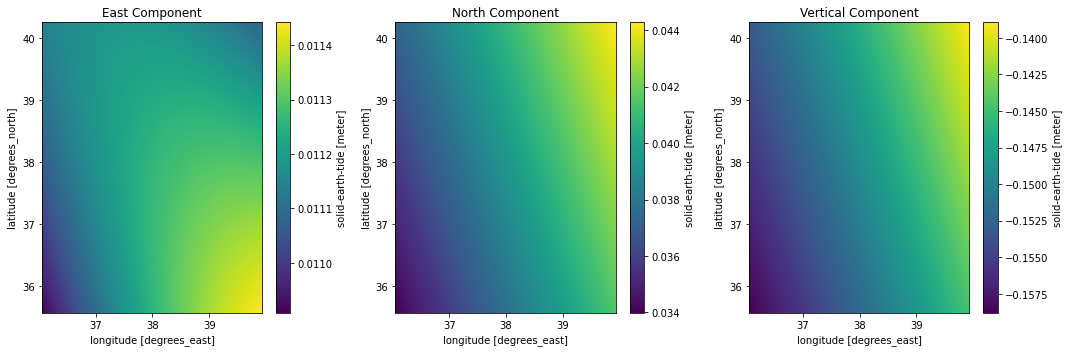

In [4]:
import matplotlib.pyplot as plt
import xarray as xr

# Load datasets
efile = xr.load_dataset(e_file)
nfile = xr.load_dataset(n_file)
ufile = xr.load_dataset(u_file)

# Create 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot east component
efile.z.plot(ax=axes[0])
axes[0].set_title('East Component')

# Plot north component
nfile.z.plot(ax=axes[1])
axes[1].set_title('North Component')

# Plot vertical component
ufile.z.plot(ax=axes[2])
axes[2].set_title('Vertical Component')

plt.tight_layout()
plt.show()


In [5]:
framedir='/gws/nopw/j04/nceo_geohazards_vol1/public/LiCSAR_products/116/116A_05207_252525/metadata'

In [6]:
os.listdir(framedir)

['116A_05207_252525-poly.txt',
 '116A_05207_252525.geo.E.azi.tif',
 '116A_05207_252525.geo.E.tif',
 '116A_05207_252525.geo.N.azi.tif',
 '116A_05207_252525.geo.N.tif',
 '116A_05207_252525.geo.U.azi.tif',
 '116A_05207_252525.geo.U.tif',
 '116A_05207_252525.geo.hgt.tif',
 '116A_05207_252525.geo.hillshade.nc',
 '116A_05207_252525.geo.landmask.tif',
 '116A_05207_252525.geo.vlos_eur.tif',
 '20160112_20160124.geo.sbovl_scaling.tif',
 'baselines',
 'lackifg.txt',
 'metadata.txt',
 'missing_sbovl',
 'network.png',
 'network_bovl.png']

In [7]:
N=lu.load_tif2xr(os.path.join(framedir, '116A_05207_252525.geo.N.azi.tif'))
E=lu.load_tif2xr(os.path.join(framedir, '116A_05207_252525.geo.E.azi.tif'))
U=lu.load_tif2xr(os.path.join(framedir, '116A_05207_252525.geo.U.azi.tif'))

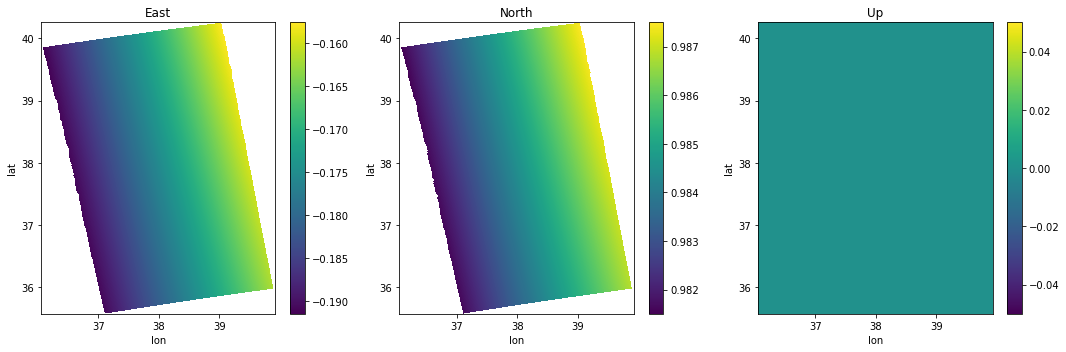

In [8]:
import matplotlib.pyplot as plt
import xarray as xr


# Create 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot east component
E.plot(ax=axes[0])
axes[0].set_title('East')

# Plot north component
N.plot(ax=axes[1])
axes[1].set_title('North')

# Plot vertical component
U.plot(ax=axes[2])
axes[2].set_title('Up')

plt.tight_layout()
plt.show()


In [9]:
# def EN2azi(N, E, heading = -169):
#ascending: around -13
#descending: around -169 (or around 13, doesn't matter)
heading=-10.121486
alpha = np.deg2rad(heading)
#thanks Chris Rollins!!!!
# return E*np.sin(alpha)+N*np.cos(alpha)
print(f'E:{np.sin(alpha)}, N:{np.cos(alpha)}')


E:-0.1757359038659772, N:0.9844373479772127


In [10]:
N_r=lu.load_tif2xr(os.path.join(framedir, '116A_05207_252525.geo.N.tif'))
E_r=lu.load_tif2xr(os.path.join(framedir, '116A_05207_252525.geo.E.tif'))
U_r=lu.load_tif2xr(os.path.join(framedir, '116A_05207_252525.geo.U.tif'))

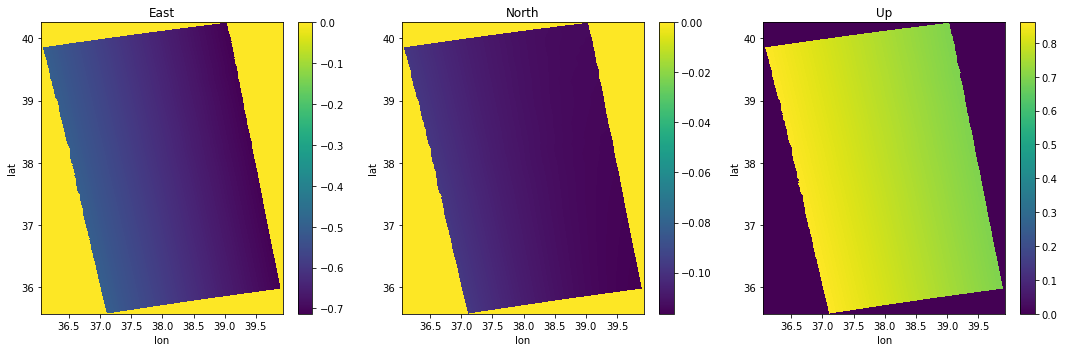

In [11]:
import matplotlib.pyplot as plt
import xarray as xr


# Create 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot east component
E_r.plot(ax=axes[0])
axes[0].set_title('East')

# Plot north component
N_r.plot(ax=axes[1])
axes[1].set_title('North')

# Plot vertical component
U_r.plot(ax=axes[2])
axes[2].set_title('Up')

plt.tight_layout()
plt.show()


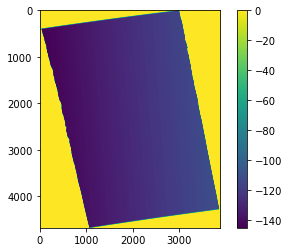

In [23]:
plt.imshow((N_r.data*nfile.z.data+E_r.data*efile.z.data+U_r.data*ufile.z.data)*1000)
plt.colorbar()

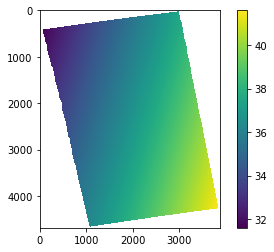

In [24]:
plt.imshow((N.data*nfile.z.data+E.data*efile.z.data+U.data*ufile.z.data)*)
plt.colorbar()

In [27]:
def project_displacement(N, E, U, n_z, e_z, u_z):
    projected = (N.data * n_z + E.data * e_z + U.data * u_z) * 1000
    projected[projected == 0] = np.nan
    return projected


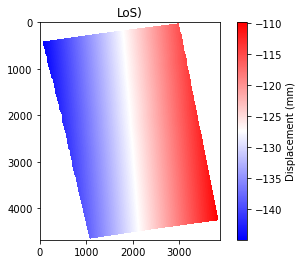

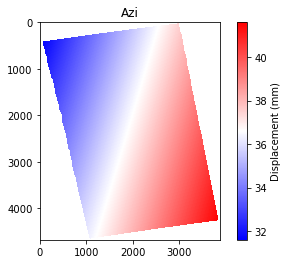

In [30]:
data = project_displacement(N_r, E_r, U_r, nfile.z.data, efile.z.data, ufile.z.data)
plt.imshow(data, cmap='bwr')
plt.colorbar(label='Displacement (mm)')
plt.title('LoS)')
plt.show()

data2 = project_displacement(N, E, U, nfile.z.data, efile.z.data, ufile.z.data)
plt.imshow(data2, cmap='bwr')
plt.colorbar(label='Displacement (mm)')
plt.title('Azi')
plt.show()
